# Differential Abundance Analysis

With this analysis we want to  test whether individual ASVs/taxa differ in abundance between samples' groups - the type analysis known as differential abundance. We will use ANCOM-BC (analysis of composition of microbiomes with bias correction): a compositionally aware alternative that allows to test for differentially abundant features.

## Setup

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy.stats import shapiro, kruskal, f_oneway


data_dir = '/home/jovyan/Group_Project/UpDoG' 
    
%matplotlib inline

In [2]:
!ls -l /home/jovyan/Group_Project/UpDoG

total 891876
drwxr-xr-x 2 jovyan jovyan     4096 Nov 25 10:24 'Differential Abundance Old'
-rw-r--r-- 1 jovyan jovyan   300219 Nov 26 10:54  Differentiao_Abundance_Analysis.ipynb
drwxr-xr-x 2 jovyan jovyan     4096 Nov 13 23:16  Results_Abundance_Estimation
-rw-r--r-- 1 jovyan jovyan   624233 Nov 17 17:28  alpha-rarefaction.qzv
-rw-r--r-- 1 jovyan jovyan 46089938 Nov 25 11:08  ancombc_FarmFish_da_barplot.qzv
-rw-r--r-- 1 jovyan jovyan 45895538 Nov 25 11:07  ancombc_FarmFish_differentials.qza
-rw-r--r-- 1 jovyan jovyan 46090217 Nov 25 11:08  ancombc_FarmFish_results.qzv
-rw-r--r-- 1 jovyan jovyan 46089822 Nov 25 11:12  ancombc_FarmHun_da_barplot.qzv
-rw-r--r-- 1 jovyan jovyan 45895463 Nov 25 11:11  ancombc_FarmHun_differentials.qza
-rw-r--r-- 1 jovyan jovyan 46090082 Nov 25 11:13  ancombc_FarmHun_results.qzv
-rw-r--r-- 1 jovyan jovyan 46090446 Nov 25 10:41  ancombc_FarmWest_da_barplot.qzv
-rw-r--r-- 1 jovyan jovyan 45896020 Nov 25 10:40  ancombc_FarmWest_differentials.qza
-rw-r--r-- 1 j

## 1. Data Exploration

In [7]:
data = q2.Artifact.load(f'{data_dir}/updog-feature-table.qza').view(pd.DataFrame)
data.head()

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


,0024a950-f4ad-4c18-a733-2050ee75184d,00290f32-cf20-4f2c-ae3b-160c75e28ea9,0032a0b3-ea8e-4024-a0a6-d873887f8a44,003b7e1f-f277-4c16-80a1-b4e02ca7fa7f,005525d2-7aa9-436f-a536-1c4234e782a7,006c42e8-3e46-40c7-b53c-60b810c7ddac,007b3451-6bc6-4fee-a716-6001b43e74f0,007e8510-72ae-4837-a4f6-2152c303bf25,0080aa29-a268-471f-b29e-f6f8128e0a62,008ac5de-ff0c-48ea-a8b1-de1a81df476b,...,ff889a3b-b97c-4516-8cbd-a7df6605d7ef,ff962d0d-5fb3-44c4-b100-aed40c1a32dd,ff98cd34-c9c9-4de2-b82f-f50c03832377,ff9adcce-7c67-40a4-9e94-2aa0777c1e36,ff9f75a3-89e5-4f60-a27f-8dd030fac145,ffaab7a6-a7ad-494c-828b-4d58e4ed1bf4,ffd2a7b5-d075-4929-a6db-485299996f7f,ffd4cbf5-7b3f-4480-9ed1-4dd18c1a7734,ffd4f8ae-1325-41ee-84fb-bdd74412ab73,ffdfd3f1-e9f7-4ee1-9eef-59ed0a1b6620
ERR2619707,103.807271,2.290796,42.427880,471.058609,278.755176,50.172306,4.782074,24.356805,76.227836,3.041216,...,15.786674,32.890911,95.119144,0.624413,1.258749,356.361348,13.000133,8.845186,14.463506,15.688009
ERR2619708,83.598821,1.819477,410.342125,32.328933,42.770201,1112.652408,0.520938,60.294359,264.622653,1.264152,...,11.483930,168.117865,69.411486,0.331138,9.300863,193.380497,97.994014,278.772887,5643.618098,6.238385
ERR2619709,13.909087,36.636840,184.686526,60.912226,576.560418,1984.583817,131.420285,40.621447,43.282710,27.243514,...,19.964331,16.142701,116.051221,1.390558,8.250856,142.221806,21.044646,16.292433,34.042237,32.766847
ERR2619710,45.196743,2.443732,1635.840021,4.084571,63.425400,488.083554,97.694643,145.360794,94.405494,1.549287,...,19.479813,79.545720,23.925300,0.764782,103.480336,733.154244,137.195781,74.394614,144.106067,21.736056
ERR2619711,31.410491,93.501377,278.755282,26.766809,52.347515,823.324965,100.272753,25.594041,49.372404,4.083253,...,0.520604,272.597092,198.569217,0.712811,6.747610,155.676908,251.473786,27.934501,39.738718,118.051000


## 1.1 Histogram
Looking at top three most abundant feature IDs

NameError: name 'top3_IDs' is not defined

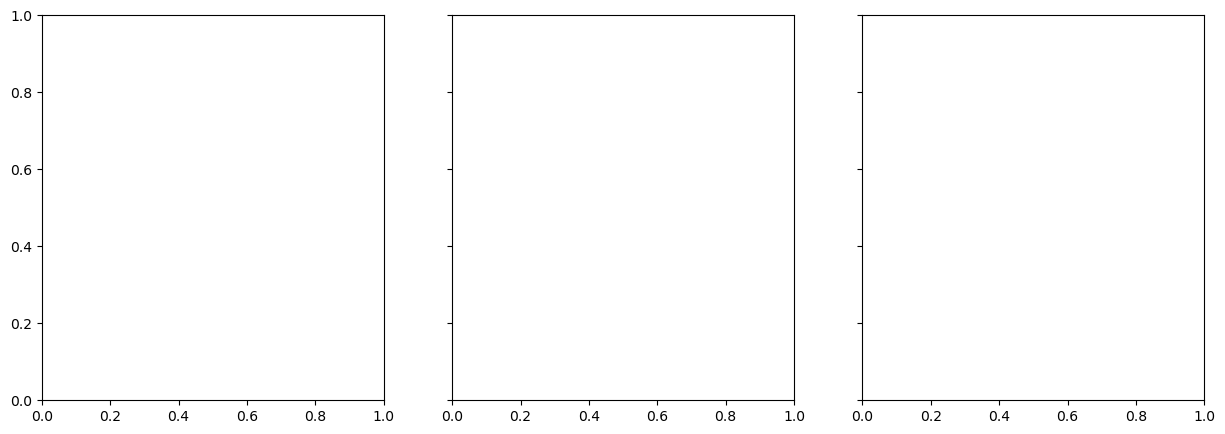

In [23]:
# Step 1: compute top 3 Feature IDs
asv_sums = data.sum(axis=0)
top3_asvs = asv_sums.sort_values(ascending=False).head(3).index
top_three = data[top3_asvs]

# Step 2: pick 3 distinct colors from the viridis palette
colors = sns.color_palette("viridis", n_colors=3)

# Step 3: plot individual histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, asv, color in zip(axes, top3_IDs, colors):
    sns.histplot(
        data=top_three[asv],
        bins=20,
        color=color,
        edgecolor='white',
        ax=ax
    )
    ax.set_title(f"ID: {asv}", fontsize=12, weight='bold')
    ax.set_xlabel("Sequence counts")
    ax.set_ylabel("Number of samples")

plt.suptitle("Top 3 Most Abundant IDs", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 1.2 Violin Plot
We need to create a new DataFrame with three columns: sample name, ASV ID and ASV abundance. We will also pick 15 samples out of the original DataFrame, to make the plot a little bit clearer.

In [11]:
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

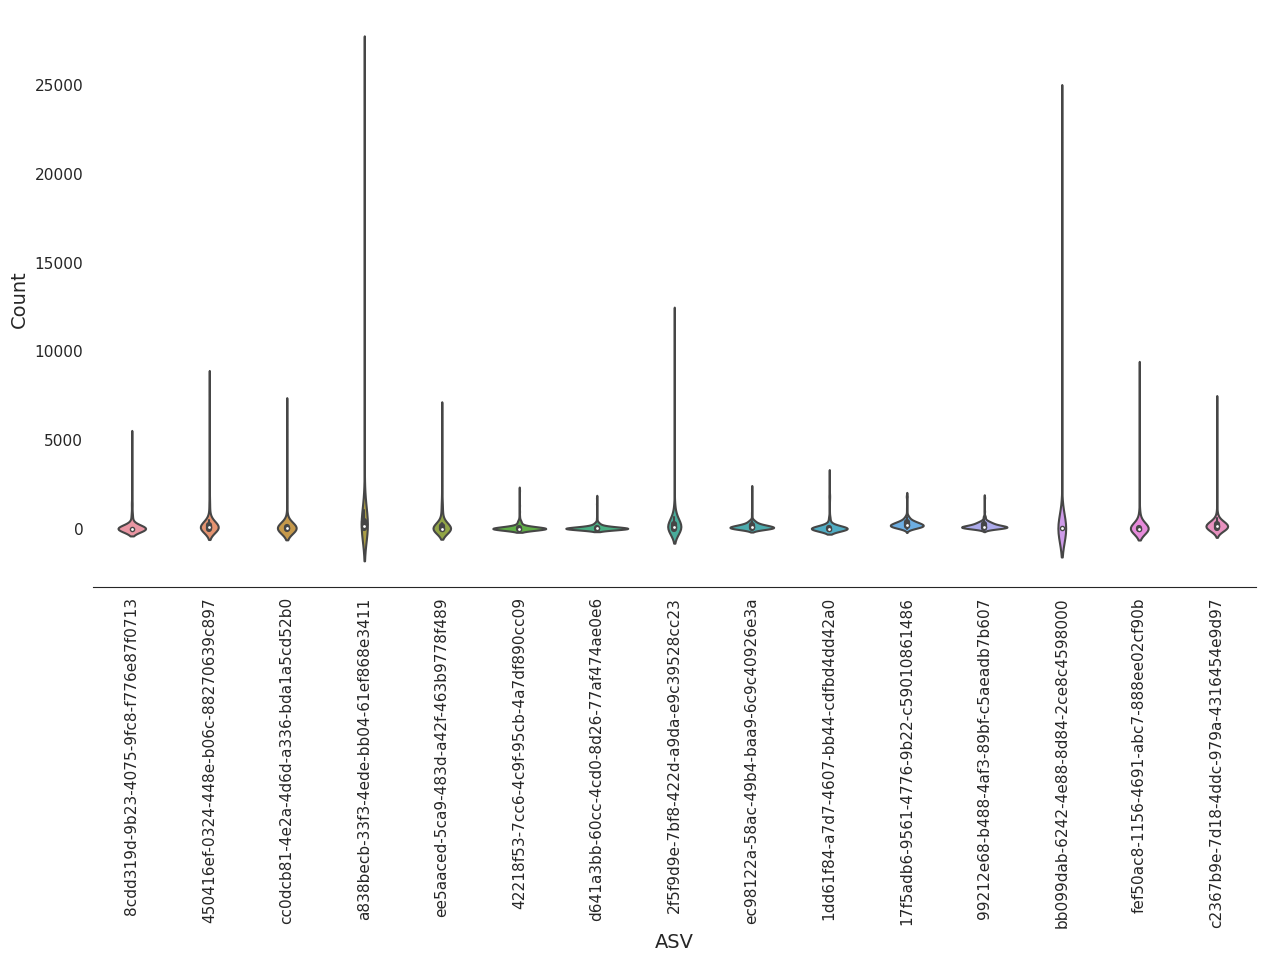

In [12]:
with sns.axes_style('white'), sns.color_palette('viridis'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

##  1.3 Shapiro-Wilk test for normality
The majority of values are focused around 0, with only some values being different. To get a more quantitative view of all the ASVs, we can additionally perform a statistical test for data normality. 

In [13]:
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [14]:
results_df

,p,is_normal
0024a950-f4ad-4c18-a733-2050ee75184d,7.996874e-21,False
00290f32-cf20-4f2c-ae3b-160c75e28ea9,4.914691e-23,False
0032a0b3-ea8e-4024-a0a6-d873887f8a44,2.240806e-18,False
003b7e1f-f277-4c16-80a1-b4e02ca7fa7f,1.864532e-22,False
005525d2-7aa9-436f-a536-1c4234e782a7,9.661193e-16,False
...,...,...
ffaab7a6-a7ad-494c-828b-4d58e4ed1bf4,6.972997e-15,False
ffd2a7b5-d075-4929-a6db-485299996f7f,1.996807e-22,False
ffd4cbf5-7b3f-4480-9ed1-4dd18c1a7734,2.401881e-21,False
ffd4f8ae-1325-41ee-84fb-bdd74412ab73,6.576007e-23,False


To check whether there is any ASV that does have normal distribution, we sum all the values from the is_normal column: True values are equivalent to 1 and False values to 0 so if the sum is bigger than 0, then we have some ASVs that are distributed normally:

In [15]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


Try again with violin plot:

## 2. ANCOM with Taxa

We filter our feature table and only retain features that are present at some minimal frequency (25) and in at least 4 samples. This can improve resolution and limit FDR (false discovery rate) penalty on features that are too far below the noise threshhold to be applicable to a statistical test.

Let's try to see what happens when we collapse the taxa down to the genus level. We can do the using the collapse action from the taxa plugin:

## Our Taxonomy File:

In [4]:
!qiime tools peek mags-table-filtered-milo-no-unassigned.qza

UUID:        8bda5b20-e9a1-4927-a5bc-b2dce644942a
Type:        FeatureTable[Frequency]
Data format: BIOMV210DirFmt


In [5]:
!qiime tools peek kraken2-mags-taxonomy_db16_milo.qza

UUID:        27a95bcd-d412-4336-9955-c948c3c3fe7f
Type:        FeatureData[Taxonomy]
Data format: TSVTaxonomyDirectoryFormat


In [8]:
! qiime taxa collapse \
    --i-table $data_dir/mags-table-filtered-milo-no-unassigned.qza \
    --i-taxonomy $data_dir/kraken2-mags-taxonomy_db16_milo.qza \
    --p-level 6 \
    --o-collapsed-table $data_dir/table_abund_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_l6.qza


In [11]:
!qiime taxa collapse --help

Usage: qiime taxa collapse [OPTIONS]

  Collapse groups of features that have the same taxonomic assignment through
  the specified level. The frequencies of all features will be summed when
  they are collapsed.

Inputs:
  --i-table ARTIFACT FeatureTable[Frequency]
                         Feature table to be collapsed.             [required]
  --i-taxonomy ARTIFACT FeatureData[Taxonomy]
                         Taxonomic annotations for features in the provided
                         feature table. All features in the feature table must
                         have a corresponding taxonomic annotation. Taxonomic
                         annotations that are not present in the feature table
                         will be ignored.                           [required]
Parameters:
  --p-level INTEGER      The taxonomic level at which the features should be
                         collapsed. All ouput features will have exactly this
                         many levels of taxonomic 

We want to first find taxa differentially abundant in between samples. For this purpose, we can filter the feature table to only contain samples from these two environments as follows:

## Farmer - Western

In [7]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='Western'" \
    --o-filtered-table $data_dir/table_abund_FarmWest_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_Far_West_l6.qza


Let's try to investigate the differential abundance across different **env**ironments:

In [8]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmWest_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_subsistence_differentials.qza #FarmWest!!

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_subsistence_differentials.qza \
    --o-visualization $data_dir/ancombc_subsistence_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_subsistence_differentials.qza \
    --o-visualization $data_dir/ancombc_subsistence_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_subsistence_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_subsistence_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptool

In [11]:
Visualization.load(f"{data_dir}/ancombc_FarmWest_da_barplot.qzv")

<visualization: Visualization uuid: d5cb51a4-0598-4a92-9eb4-37bba06bb2c4>

In [12]:
Visualization.load(f"{data_dir}/ancombc_FarmWest_results.qzv")

<visualization: Visualization uuid: 02ab2297-8d00-42dc-9986-c17af741cf04>

## Farmer - Fisher

In [17]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='Fisher'" \
    --o-filtered-table $data_dir/table_abund_FarmFish_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_FarmFish_l6.qza


In [20]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmFish_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FarmFish_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FarmFish_differentials.qza \
    --o-visualization $data_dir/ancombc_FarmFish_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FarmFish_differentials.qza \
    --o-visualization $data_dir/ancombc_FarmFish_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmFish_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmFish_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa

In [21]:
Visualization.load(f"{data_dir}/ancombc_FarmFish_da_barplot.qzv")

<visualization: Visualization uuid: d97f6022-cf6a-4fc9-aedb-f17ad5ae6275>

In [22]:
Visualization.load(f"{data_dir}/ancombc_FarmFish_results.qzv")

<visualization: Visualization uuid: 6fd87445-cefc-43a6-932d-79ac6c6641e4>

## Farmer - Hunter Gatherer

In [23]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Farmer' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_FarmHun_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_FarmHun_l6.qza


In [24]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FarmHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FarmHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FarmHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FarmHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FarmHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FarmHun_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmHun_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: /home/jovyan/Group_Project/UpDoG/ancombc_FarmHun_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.i

In [25]:
Visualization.load(f"{data_dir}/ancombc_FarmHun_da_barplot.qzv")

<visualization: Visualization uuid: a1855c2f-fa27-4575-bb87-1e930ff7c0a7>

In [26]:
Visualization.load(f"{data_dir}/ancombc_FarmHun_results.qzv")

<visualization: Visualization uuid: c158e0c8-4667-44b1-9ab4-78174f8429ff>

## Western - Fisher

In [14]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Fisher' or [subsistence_mode]='Western'" \
    --o-filtered-table $data_dir/table_abund_WestFish_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_WestFish_l6.qza


In [15]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_WestFish_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_WestFish_differentials.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Plugin error from composition:

  ('Value provided in `reference_levels` parameter not associated with any IDs in the feature table. Please make sure the value(s) selected in each column::value pair are associated with IDs present in the feature table. \n\n Value not associated with any IDs in the table: "Farmer"', ' IDs not found in table: "Index([\'ERR2619723\', \'ERR2619724\', \'ERR2619725\', \'ERR2619726\', \'ERR2619727\',\n       \'ERR2619728\', \'ERR2619729\', \'ERR2619730\', \'ERR2619731\', \'ERR2619732\',\n       \'ERR2619733\', \'ERR2619734\', \'ERR2619735\', \'ERR2619736\', \'ERR2619737\',\n       \'ERR2619738\', \'ERR2619739\', \'ERR2619740\', \'ERR2619

In [17]:
!qiime metadata tabulate \
  --m-input-file $data_dir/table_abund_WestFish_l6.qza \
  --o-visualization table_abund_WestFish_l6.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: table_abund_WestFish_l6.qzv


In [8]:
# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_WestFish_differentials.qza \
    --o-visualization $data_dir/ancombc_WestFish_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_WestFish_differentials.qza \
    --o-visualization $data_dir/ancombc_WestFish_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Plugin error from composition:

  ('Value provided in `reference_levels` parameter not associated with any IDs in the feature table. Please make sure the value(s) selected in each column::value pair are associated with IDs present in the feature table. \n\n Value not associated with any IDs in the table: "Farmer"', ' IDs not found in table: "Index([\'ERR2619723\', \'ERR2619724\', \'ERR2619725\', \'ERR2619726\', \'ERR2619727\',\n       \'ERR2619728\', \'ERR2619729\', \'ERR2619730\', \'ERR2619731\', \'ERR2619732\',\n       \'ERR2619733\', \'ERR2619734\', \'ERR2619735\', \'ERR2619736\', \'ERR2619737\',\n       \'ERR2619738\', \'ERR2619739\', \'ERR2619740\', \'ERR2619

## Western - HunGat

In [5]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Western' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_WestHun_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: /home/jovyan/Group_Project/UpDoG/table_abund_WestHun_l6.qza


In [6]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_WestHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_WestHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_WestHun_differentials.qza \
    --o-visualization $data_dir/ancombc_WestHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_WestHun_differentials.qza \
    --o-visualization $data_dir/ancombc_WestHun_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Plugin error from composition:

  ('Value provided in `reference_levels` parameter not associated with any IDs in the feature table. Please make sure the value(s) selected in each column::value pair are associated with IDs present in the feature table. \n\n Value not associated with any IDs in the table: "Farmer"', ' IDs not found in table: "Index([\'ERR2619723\', \'ERR2619724\', \'ERR2619725\', \'ERR2619726\', \'ERR2619727\',\n       \'ERR2619728\', \'ERR2619729\', \'ERR2619730\', \'ERR2619731\', \'ERR2619732\',\n       \'ERR2619733\', \'ERR2619734\', \'ERR2619735\', \'ERR2619736\', \'ERR2619737\',\n       \'ERR2619738\', \'ERR2619739\', \'ERR2619740\', \'ERR2619

## Fisher - HunGat

In [ ]:
! qiime feature-table filter-samples \
    --i-table $data_dir/table_abund_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-where "[subsistence_mode]='Fisher' or [subsistence_mode]='HunGat'" \
    --o-filtered-table $data_dir/table_abund_FishHun_l6.qza

In [ ]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $data_dir/table_abund_FishHun_l6.qza \
    --m-metadata-file $data_dir/updog_metadata.tsv \
    --p-formula subsistence_mode \
    --o-differentials $data_dir/ancombc_FishHun_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $data_dir/ancombc_FishHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FishHun_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $data_dir/ancombc_FishHun_differentials.qza \
    --o-visualization $data_dir/ancombc_FishHun_results.qzv